<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/floor_detection_aditya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/floor_detection.zip"
extract_path = "/content/floor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted!")

Dataset Extracted!


In [3]:
import tensorflow as tf #for ML library
from tensorflow.keras import layers, models #layers(building blocks), models(to create a model)
import matplotlib.pyplot as plt #to make plots and show images

In [7]:
IMG_SIZE = (224,224) #Images will be resized to 224*224 pixels
BATCH = 32 #number of images per batch
PATH = "/content/floor_dataset"

In [8]:
#load training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="training", #80% training data
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical"
)

Found 242 files belonging to 2 classes.
Using 194 files for training.


In [9]:
#load validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="validation", #20% validation data
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical"
)

Found 242 files belonging to 2 classes.
Using 48 files for validation.


In [10]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['X', 'Y']


In [11]:
# Build the model
base = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights=None) #<---"imagenet" if you need accuracy

base.trainable = False #keep frozen (do not train base model)
inputs = layers.Input(shape=IMG_SIZE+(3,)) #define input (224, 224, 3 image)
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs) #preprocess image
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x) #make features smaller
#final layer, one neuron per class
outputs = layers.Dense(len(class_names), activation="softmax")(x)
#create full model
model = models.Model(inputs, outputs)
#compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

#train the model for 5 epochs
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.5052 - loss: 0.6932 - val_accuracy: 0.4792 - val_loss: 0.6932
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.5052 - loss: 0.6932 - val_accuracy: 0.4792 - val_loss: 0.6934
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.4792 - val_loss: 0.6935
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.4792 - val_loss: 0.6936
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.4792 - val_loss: 0.6936


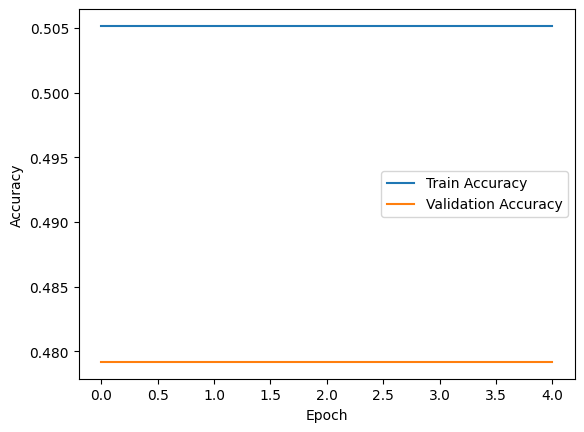

In [12]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

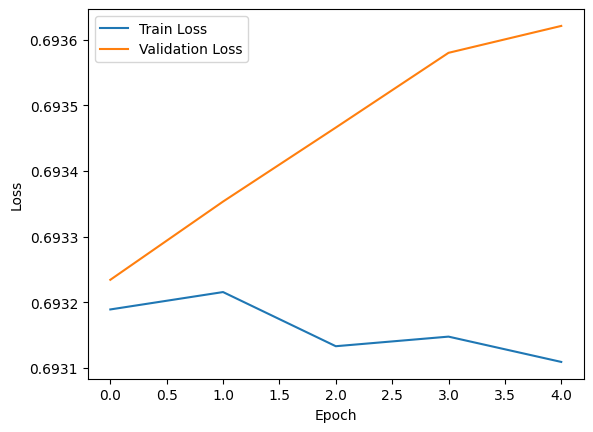

In [13]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

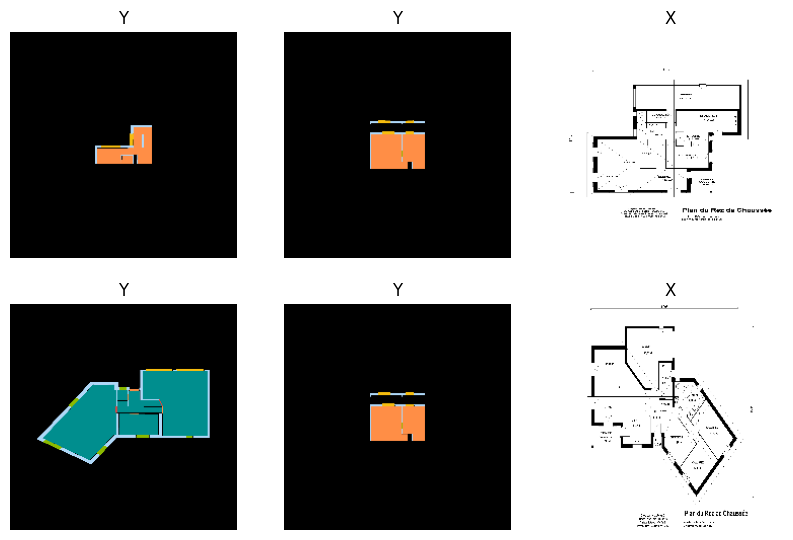

In [15]:
import numpy as np

# take one batch from train_ds
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))   # create big figure 10x10
    for i in range(6):             # show first 6 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))   # show image
        plt.title(class_names[np.argmax(labels[i])])    # show class name
        plt.axis("off")   # Hide axes

In [16]:
# Save the trained model
model.save('/content/floor_detection_model.h5')
print("Model saved to /content/floor_detection_model.h5")

Model saved to /content/floor_detection_model.h5
